# Model 1: From Scratch DCNN
Designed by: Theo Negrao

A small VGG-style CNN trained from scratch.

### Iterations

| Version | Change | Test accuracy | Test macro F1 | Test weighted F1 | Decision |
|---|---|---:|---:|---:|---|
| V0 | Baseline CNN: 4 conv blocks, Flatten head | 0.736 | 0.704 | 0.743 | Baseline |
| V1 | Replaced Flatten with GlobalAveragePooling2D | 0.705 | 0.677 | 0.704 | Rejected: reduced capacity too much |
| V2 | Expanded to small VGG-style CNN with paired conv layers | 0.587 | 0.514 | 0.566 | Rejected: harder to optimise / underfit |
| V4 | Best previous model + lower learning rate | 0.736 | 0.693 | 0.741 | Rejected: similar accuracy but lower macro F1 |
| V5 | Best previous model + less augmentation | 0.764 | 0.728 | 0.768 | Kept |

In [1]:
import sys
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sys.path.append("..")
from shared_utils import (
    PROJECT_ROOT,
    load_data,
    eval_model,
    save_metrics,
    plot_training_history,
    get_class_weights,
)

2026-05-29 14:55:28.448851: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780066528.464308    5409 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780066528.468990    5409 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780066528.482606    5409 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780066528.482631    5409 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780066528.482634    5409 computation_placer.cc:177] computation placer alr

In [2]:
# Configurations

# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)

# Directory to save figures
FIGURES_DIR = PROJECT_ROOT / "scratch_cnn" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Data Loading
data = load_data()

train_paths = data["train_paths"]
val_paths = data["val_paths"]
test_paths = data["test_paths"]

train_labels = data["train_labels"]
val_labels = data["val_labels"]
test_labels = data["test_labels"]

class_list = data["class_list"]
NUM_CLASSES = len(class_list)

print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))
print("Classes:", class_list)

print()
print("Example train image:")
print(train_paths[0])
print("Exists:", Path(train_paths[0]).exists())

Train: 10859
Val: 2328
Test: 2328
Classes: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']

Example train image:
/home/n11902736/cab420/WasteClassification/data/garbage_classification/clothes/clothes3810.jpg
Exists: True


## Data Preprocessing
2 datasets created:
 - train_ds = shuffled, augmented during training
 - train_eval_ds = not shuffled, used only for train-set predictions/evaluation

Preprocessing:
 - resize to 128x128
 - normalize to [0,1]
 - augmentations:
    - Horizontal Flip
    - Rotation
    - Zoom
    - Translation

In [4]:
# Image loading settings
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

I0000 00:00:1780066531.179749    5409 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1880 MB memory:  -> device: 0, name: NVIDIA A16-4Q, pci bus id: 0000:04:04.0, compute capability: 8.6


Datasets created.


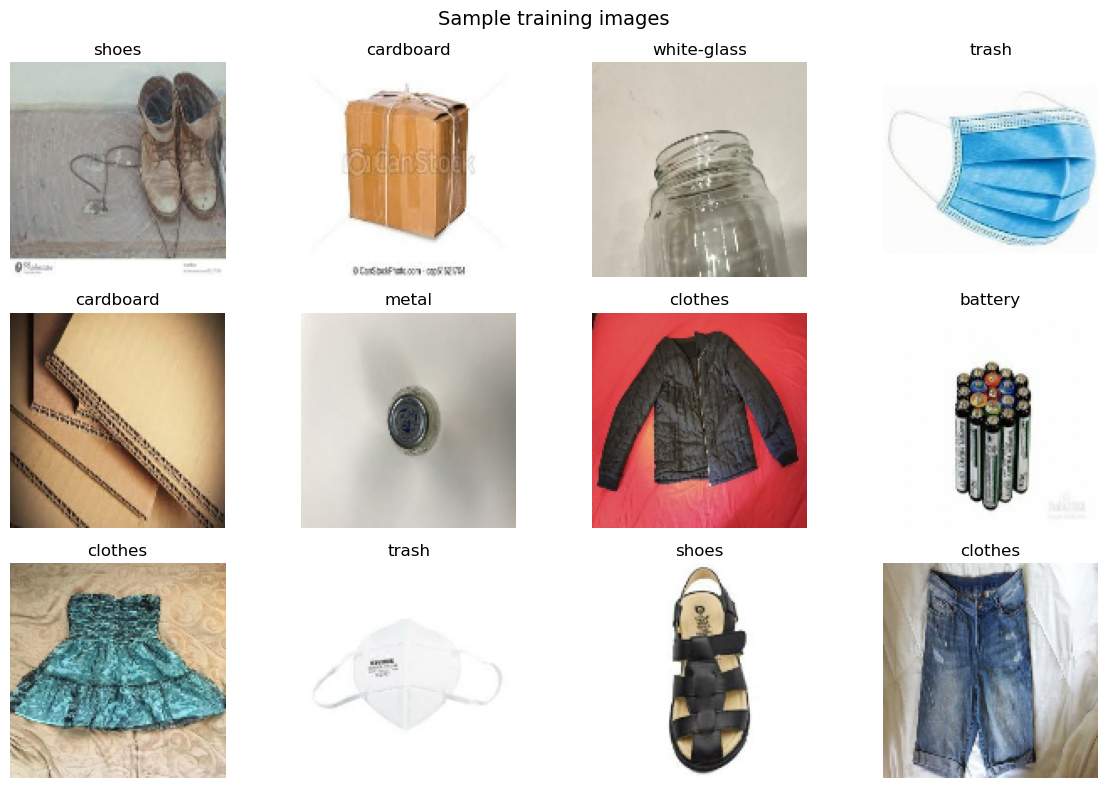

Saved: /home/n11902736/cab420/WasteClassification/scratch_cnn/figures/sample_training_images.png


In [5]:
def load_image(path, label):
    """
    Load one image file and return image tensor plus label.

    Images are:
    - decoded as RGB
    - resized to IMG_SIZE
    - normalised to [0, 1]
    """
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label


train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=2000, seed=RANDOM_STATE, reshuffle_each_iteration=False,)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Non-shuffled version for train-set evaluation later.
train_eval_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_eval_ds = train_eval_ds.map(load_image, num_parallel_calls=AUTOTUNE)
train_eval_ds = train_eval_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(load_image, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Datasets created.")

# Visualize training batch
images, labels = next(iter(train_ds))

fig = plt.figure(figsize=(12, 8))

for i in range(12):
    ax = fig.add_subplot(3, 4, i + 1)
    ax.imshow(images[i])
    ax.set_title(class_list[int(labels[i])])
    ax.axis("off")

fig.suptitle("Sample training images", fontsize=14)
plt.tight_layout()

figure_path = FIGURES_DIR / "sample_training_images.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

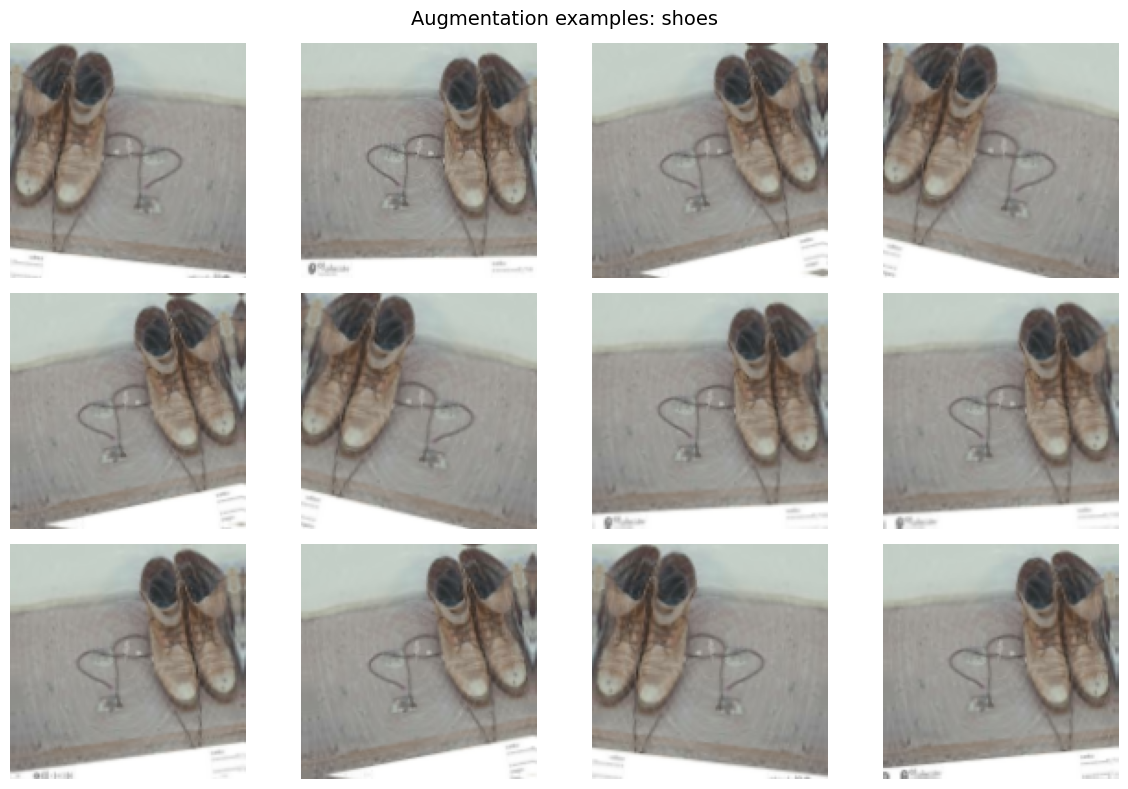

Saved: /home/n11902736/cab420/WasteClassification/scratch_cnn/figures/augmentation_examples.png


In [6]:
# Data Augmentation
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=RANDOM_STATE),
        layers.RandomRotation(0.04, seed=RANDOM_STATE),
        layers.RandomZoom(0.05, seed=RANDOM_STATE),
    ],
    name="data_augmentation",
)

# Visualize examples
sample_image = images[0]

fig = plt.figure(figsize=(12, 8))

for i in range(12):
    ax = fig.add_subplot(3, 4, i + 1)
    augmented = data_augmentation(tf.expand_dims(sample_image, axis=0), training=True)
    ax.imshow(augmented[0])
    ax.axis("off")

fig.suptitle(f"Augmentation examples: {class_list[int(labels[0])]}", fontsize=14)
plt.tight_layout()

figure_path = FIGURES_DIR / "augmentation_examples.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

## Class Weights
Attempt to compensate class imbalance: large 'clothes' class in relation to others.
- This does not change the validation/test distribution, it only affects the loss during training.

In [7]:
class_weights = get_class_weights(train_labels)

print("Class weights:")
for label, weight in class_weights.items():
    print(f"{label:>2d} {class_list[label]:>15s}: {weight:.3f}")

Class weights:
 0         battery: 1.369
 1      biological: 1.313
 2     brown-glass: 2.129
 3       cardboard: 1.453
 4         clothes: 0.243
 5     green-glass: 2.052
 6           metal: 1.679
 7           paper: 1.231
 8         plastic: 1.496
 9           shoes: 0.654
10           trash: 1.854
11     white-glass: 1.667


## Build From Scratch DCNN
Small VGG-style CNN.

In [8]:
def build_scratch_cnn(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)

    x = data_augmentation(inputs)

    # Block 1
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Classifier head
    x = layers.Flatten()(x)
    x = layers.Dropout(0.50, seed=RANDOM_STATE)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.40, seed=RANDOM_STATE)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="scratch_cnn_vgg_style")

    return model

# Reproducibility: Clear old model state before creating a new model, reset seeds
keras.backend.clear_session()
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)

# Create Model
model = build_scratch_cnn(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES,
)

model.summary()

Model: "scratch_cnn_vgg_style"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,482,988 (17.10 MB)

 Trainable params: 4,482,988 (17.10 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Training settings
EPOCHS = 50
LEARNING_RATE = 1e-3
PATIENCE = 8

In [10]:
# Compile Model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Set Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
    )
]

# Train Model
start_time = time.perf_counter()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights,
)
train_time = time.perf_counter() - start_time

print(f"Training time: {train_time:.2f}s")

Epoch 1/50


I0000 00:00:1780066537.523925    5448 cuda_dnn.cc:529] Loaded cuDNN version 90300


340/340 ━━━━━━━━━━━━━━━━━━━━ 30s 71ms/step - accuracy: 0.2685 - loss: 2.1317 - val_accuracy: 0.3613 - val_loss: 1.8367
Epoch 2/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - accuracy: 0.4162 - loss: 1.7375 - val_accuracy: 0.5103 - val_loss: 1.5390
Epoch 3/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.5001 - loss: 1.5324 - val_accuracy: 0.5893 - val_loss: 1.2798
Epoch 4/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.5332 - loss: 1.4368 - val_accuracy: 0.5803 - val_loss: 1.2600
Epoch 5/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - accuracy: 0.5449 - loss: 1.3827 - val_accuracy: 0.6001 - val_loss: 1.1916
Epoch 6/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - accuracy: 0.5781 - loss: 1.2976 - val_accuracy: 0.5906 - val_loss: 1.2067
Epoch 7/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - accuracy: 0.6030 - loss: 1.2310 - val_accuracy: 0.6491 - val_loss: 1.0515
Epoch 8/50
340/340 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - accuracy: 0.6129 - loss: 1.1800 - val_accurac

Saved figure to: /home/n11902736/cab420/WasteClassification/scratch_cnn/figures/scratch_CNN_training_history.png/training_accuracy.png


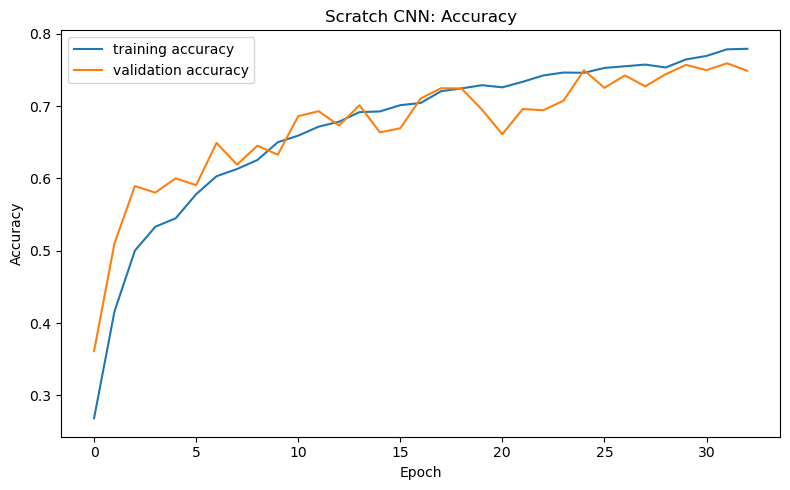

Saved figure to: /home/n11902736/cab420/WasteClassification/scratch_cnn/figures/scratch_CNN_training_history.png/training_loss.png


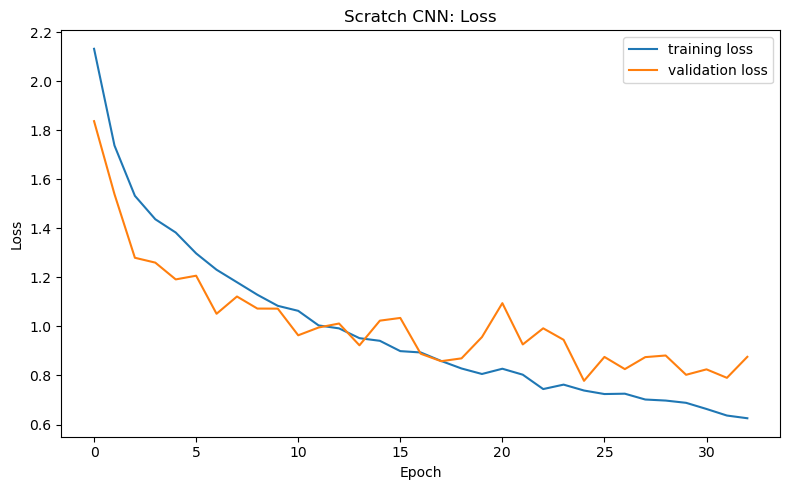

In [11]:
# Show training history plots
plot_training_history(history, title="Scratch CNN", save_dir=FIGURES_DIR/"scratch_CNN_training_history.png",)

In [12]:
# Save Training history scv for final evaluation
history_df = pd.DataFrame(history.history)

history_path = PROJECT_ROOT / "scratch_cnn" / "training_history.csv"
history_df.to_csv(history_path, index=False)

print("Saved:", history_path)
display(history_df.head())

Saved: /home/n11902736/cab420/WasteClassification/scratch_cnn/training_history.csv


,accuracy,loss,val_accuracy,val_loss
0,0.268533,2.131709,0.361254,1.836738
1,0.416153,1.737450,0.510309,1.539041
2,0.500138,1.532374,0.589347,1.279794
3,0.533198,1.436827,0.580326,1.260006
4,0.544894,1.382695,0.600086,1.191591


340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step
Scratch CNN
-----------
Training time     : 742.23s
Inference time    : 8.586s
Time per sample   : 3.688ms
-----------
              precision    recall  f1-score   support

     battery     0.6541    0.7324    0.6910       142
  biological     0.7903    0.6622    0.7206       148
 brown-glass     0.7327    0.8132    0.7708        91
   cardboard     0.7594    0.7537    0.7566       134
     clothes     0.9156    0.8686    0.8915       799
 green-glass     0.8469    0.8830    0.8646        94
       metal     0.4328    0.5043    0.4659       115
       paper     0.5159    0.8280    0.6357       157
     plastic     0.7059    0.4615    0.5581       130
       shoes     0.7382    0.5791    0.6491       297
       trash     0.6496    0.7238    0.6847       105
 white-glass     0.5746    0.6638    0.6160       116

    accuracy                         0.7418      2328
   macro avg     0.6930    0.7061    0.69

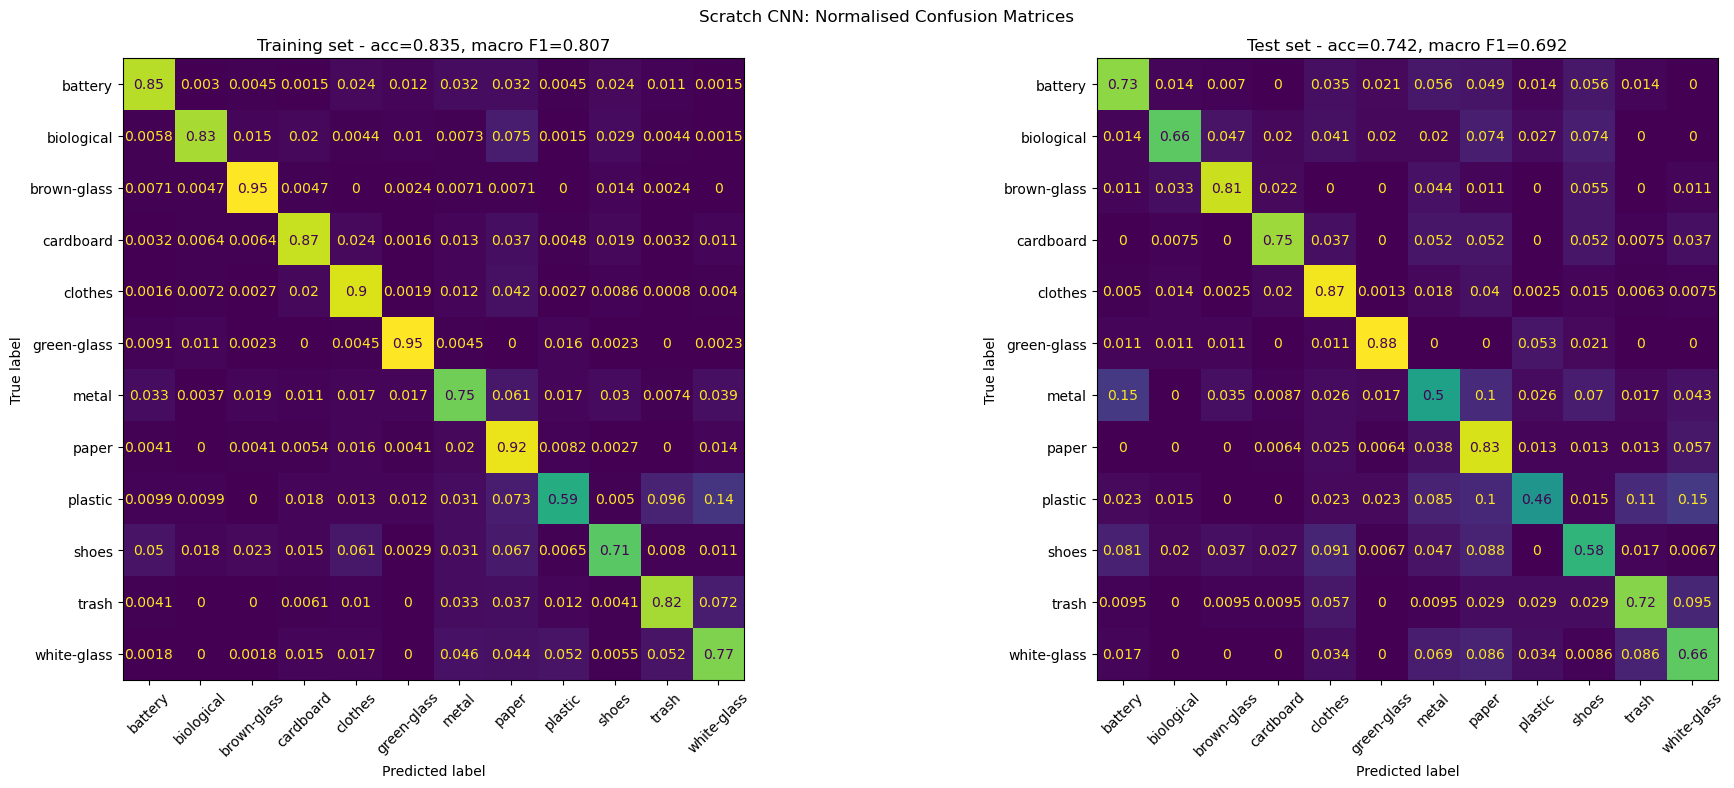

Saved metrics to: /home/n11902736/cab420/WasteClassification/scratch_cnn/scratch_cnn_metrics.json


In [13]:
# Evaluate on training and test sets
start_time = time.perf_counter()

train_prob = model.predict(train_eval_ds)
test_prob = model.predict(test_ds)

inference_time = time.perf_counter() - start_time

train_pred = np.argmax(train_prob, axis=1)
test_pred = np.argmax(test_prob, axis=1)

metrics = eval_model(
    test_labels,
    test_pred,
    class_list,
    model_name="Scratch CNN",
    y_train=train_labels,
    train_pred=train_pred,
    train_time=train_time,
    inference_time=inference_time,
    save_path=FIGURES_DIR/"scratch_cnn_confusion_matrices.png",
)

save_metrics(
    metrics,
    PROJECT_ROOT / "scratch_cnn" / "scratch_cnn_metrics.json",
)

## Save Predictions

In [14]:
predictions_df = pd.DataFrame({
    "path": test_paths,
    "true_label": test_labels,
    "true_class": [class_list[i] for i in test_labels],
    "pred_label": test_pred,
    "pred_class": [class_list[i] for i in test_pred],
    "confidence": np.max(test_prob, axis=1),
    "correct": test_labels == test_pred,
})

predictions_path = PROJECT_ROOT / "scratch_cnn" / "scratch_cnn_predictions.csv"
predictions_df.to_csv(predictions_path, index=False)

print("Saved:", predictions_path)
display(predictions_df.head())

Saved: /home/n11902736/cab420/WasteClassification/scratch_cnn/scratch_cnn_predictions.csv


,path,true_label,true_class,pred_label,pred_class,confidence,correct
0,/home/n11902736/cab420/WasteClassification/dat...,0,battery,6,metal,0.739368,False
1,/home/n11902736/cab420/WasteClassification/dat...,0,battery,9,shoes,0.854984,False
2,/home/n11902736/cab420/WasteClassification/dat...,9,shoes,0,battery,0.726954,False
3,/home/n11902736/cab420/WasteClassification/dat...,4,clothes,4,clothes,0.999523,True
4,/home/n11902736/cab420/WasteClassification/dat...,9,shoes,9,shoes,0.506369,True


## Analysis: High confidence misclassification

In [15]:
wrong_df = predictions_df[predictions_df["correct"] == False].copy()
wrong_df = wrong_df.sort_values("confidence", ascending=False)

display(wrong_df.head(12))

,path,true_label,true_class,pred_label,pred_class,confidence,correct
2063,/home/n11902736/cab420/WasteClassification/dat...,8,plastic,4,clothes,0.999049,False
1846,/home/n11902736/cab420/WasteClassification/dat...,1,biological,2,brown-glass,0.997770,False
1239,/home/n11902736/cab420/WasteClassification/dat...,1,biological,7,paper,0.996721,False
1645,/home/n11902736/cab420/WasteClassification/dat...,9,shoes,2,brown-glass,0.993925,False
1650,/home/n11902736/cab420/WasteClassification/dat...,6,metal,4,clothes,0.991143,False
44,/home/n11902736/cab420/WasteClassification/dat...,8,plastic,7,paper,0.990992,False
1940,/home/n11902736/cab420/WasteClassification/dat...,9,shoes,3,cardboard,0.989807,False
164,/home/n11902736/cab420/WasteClassification/dat...,9,shoes,4,clothes,0.986708,False
1876,/home/n11902736/cab420/WasteClassification/dat...,1,biological,0,battery,0.986198,False
487,/home/n11902736/cab420/WasteClassification/dat...,4,clothes,7,paper,0.985909,False


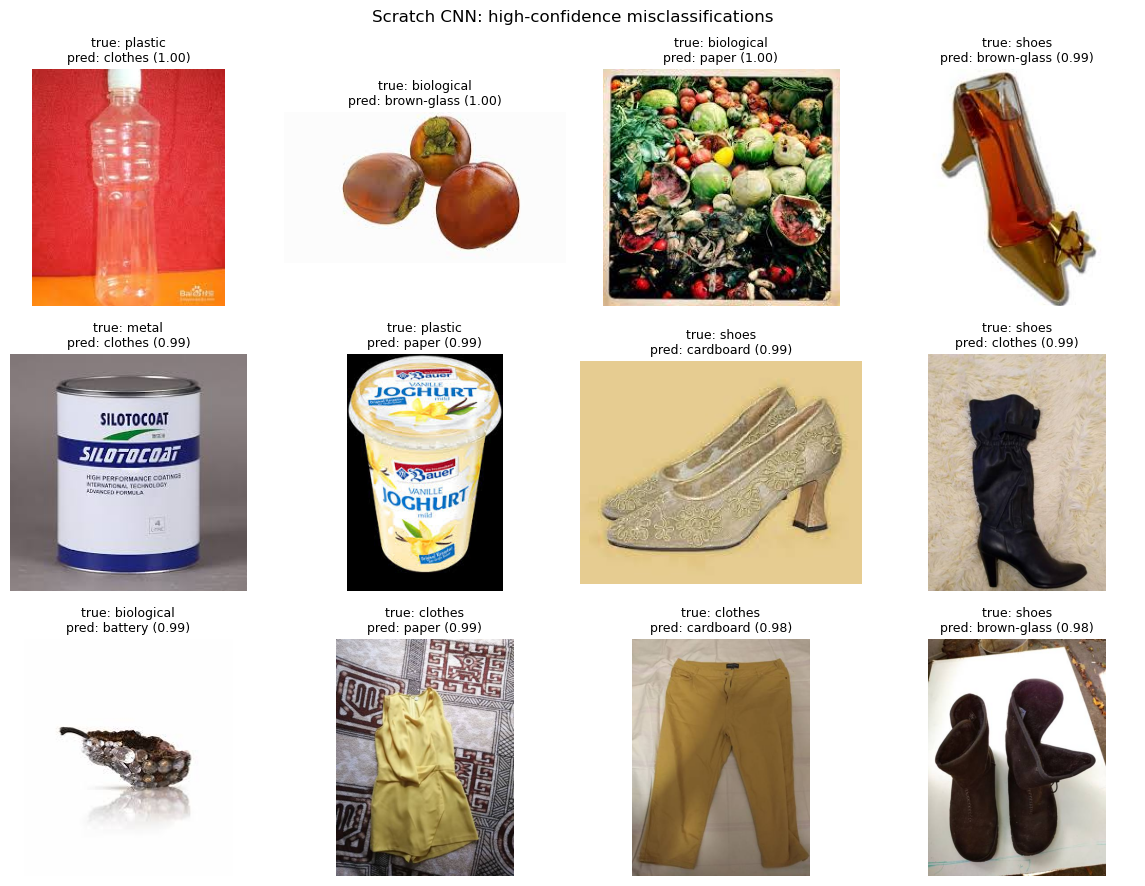

Saved: /home/n11902736/cab420/WasteClassification/scratch_cnn/figures/scratch_cnn_high_confidence_errors.png


In [16]:
# Plot examples
top_k = 12
failure_df = wrong_df.head(top_k)

n_cols = 4
n_rows = int(np.ceil(len(failure_df) / n_cols))

fig = plt.figure(figsize=(12, 3 * n_rows))

for plot_i, (_, row) in enumerate(failure_df.iterrows()):
    ax = fig.add_subplot(n_rows, n_cols, plot_i + 1)

    img = plt.imread(row["path"])
    ax.imshow(img)

    ax.set_title(
        f"true: {row['true_class']}\n"
        f"pred: {row['pred_class']} ({row['confidence']:.2f})",
        fontsize=9,
    )

    ax.axis("off")

fig.suptitle("Scratch CNN: high-confidence misclassifications", fontsize=12)
plt.tight_layout()

figure_path = FIGURES_DIR / "scratch_cnn_high_confidence_errors.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)